<a href="https://colab.research.google.com/github/malcolmlett/training-instrumentation-toolkit/blob/main/information_bottleneck.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Information Bottleneck Theory of Deep Learning

Shwartz-Ziv, R., Tishby, N. (2017). Opening the Black Box of Deep Neural Networks via Information. ArXiv. https://arxiv.org/abs/1703.00810

Tishby, N. The Information Bottleneck Theory of \[simple\] Deep Learning. https://www.youtube.com/watch?v=Zb9-1PZoAj4


In [1]:
# Install Training Instrumentation Toolkit
import os
import sys
if not os.path.isdir('training-instrumentation-toolkit'):
  !git clone https://github.com/malcolmlett/training-instrumentation-toolkit.git
sys.path.append('training-instrumentation-toolkit')

# Imports
import train_instrumentation as tinstr
import keras
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow.keras import layers, models, datasets, optimizers, metrics
import numpy as np
import matplotlib.pyplot as plt
import math
import sklearn
from scipy.ndimage import gaussian_filter1d

Cloning into 'training-instrumentation-toolkit'...
remote: Enumerating objects: 1361, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 1361 (delta 65), reused 46 (delta 22), pack-reused 1239 (from 1)
Receiving objects: 100% (1361/1361), 97.60 MiB | 14.36 MiB/s, done.
Resolving deltas: 100% (814/814), done.


## Instrumented Training Run
We'll use a simple binary classification problem, against the commonly used "circles" dataset.

We won't go into details about the various options for instrumentation in this notebook. See the _Instrumentation_ notebook for that.

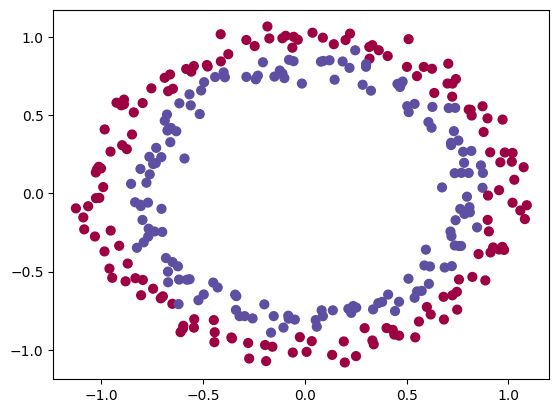

In [2]:
# Using a slightly more elaborate model than needed for such a simple task in order
# to illustrate how dropout and normalization layers appear in visualisations
def binary_classification_model():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,), name='input'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal', name='dense1'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal', name='dense2'),
    tf.keras.layers.Dropout(rate=0.2, name='dropout1'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal', name='dense3'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal', name='dense4'),
    tf.keras.layers.Dropout(rate=0.2, name='dropout2'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal', name='dense5'),
    tf.keras.layers.BatchNormalization(name='batch_norm1'),
    tf.keras.layers.Dense(5, activation='relu', kernel_initializer='he_normal', name='dense6'),
    tf.keras.layers.Dense(1, activation='sigmoid', kernel_initializer='he_normal', name='dense7')
  ])
  return model

def binary_classification_dataset():
  np.random.seed(1)
  train_X, train_Y = sklearn.datasets.make_circles(n_samples=300, noise=.05)
  train_X = train_X
  train_Y = train_Y.reshape((-1, 1))
  return train_X, train_Y

train_X, train_Y = binary_classification_dataset()
plt.scatter(train_X[:, 0], train_X[:, 1], c=train_Y, s=40, cmap=plt.cm.Spectral);
plt.show()

In [8]:
# benefit is on order of 159ms/epoch with _norm() vs 172ms/epoch with tf.norm()
def _norm(x):
  """
  More efficient equivalent of tf.norm() that directly computes the
  sqrt of the sum of squares. This is probably more efficient because it's hard-coded to compute the norm
  in just one way.
  """
  return tf.math.sqrt(tf.reduce_sum(tf.square(x)))

class GradientNormCollector(tinstr.BaseGradientCallback):
    """
    Collects the components needed to calculated gradient means and std.devs normalized by the L2-norm of the weights,
    as used by Shwartz-Ziv & Tishby.
    Only collects per-epoch asd this is intended to be used over very long training runs.

    Gradients a "normalized" mean and stddev of gradients according to the following equations. This enables us to examine
    the gradient distributions independent of the absolute scale of weights.


                                    ||E[gradients]||_2
    Normalized Mean Gradient Norm = ------------------
                                      ||weights||_2


                                    ||STD[gradients]||_2
    Normalized STD Gradient Norm = ---------------------
                                       ||weights||_2

    where:
      - E[gradients] = element-wise mean of stochastic gradients over mini-batches
      - STD[gradients] = element-wise std.dev of stochastic gradients over mini-batches
      - ||E[gradients]||_2 = L2 norm (euclidean) of the mean gradient
      - ||weights||_2 = L2 norm of the weight matrix at the end of each epoch

    As we're taking samples only at the end of the epoch we'll average the gradients over the course of the epoch.
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.epoch_gradient_means = []  # list (by-epoch) of list (by-variable) of scalar L2-norms of element-wise means of gradients
        self.epoch_gradient_stddevs = []  # list (by-epoch) of list (by-variable) of scalar L2-norms of element-wise stddevs of gradients
        self.epoch_weight_norms = []  # list (by-epoch) of list (by-variable) of scalar L2-norms of element-wise means of variables
        self._gradient_accumulator = tinstr.PerEpochAccumulatorStrategy()  # raw gradients
        self._gradient2_accumulator = tinstr.PerEpochAccumulatorStrategy()  # gradients squared

    @property
    def normalized_stats(self):
        """
        The scalar normalized means and stdevs of the gradients of each variable over the course of each
        epoch, as per the equations documented above.
        Returns:
          (grad_means, grad_stddevs), where:
            - grad_means - array (epoch, variable) of normalized gradient means
            - grad_stddevs - array (epoch, variable) of normalized gradient stddevs
        """
        grad_mean_norms, grad_stddev_norms, weight_norms = self.collected_norms
        normalized_grad_means = grad_mean_norms / weight_norms
        normalized_grad_stddevs = grad_stddev_norms / weight_norms
        return normalized_grad_means, normalized_grad_stddevs

    @property
    def normalized_stats_by_layer(self):
        """
        Selects the stats of just the main weights of each layer.
        Blindly assumes that the first variable in each layer is the main weights.
        Any layers that don't have variables are returned as None.
        Returns:
          list (by-layer) of pandas DataFrame with shape (epochs, 2) with columns containing, respectively:
            - [0] normalized mean gradient norm
            - [1] normalized stddev gradient norm
        """
        # results by trainable variable
        means, stddevs = self.normalized_stats

        # determine filter
        var_indices = tinstr.trainable_variable_indices_by_layer(self.model)
        num_layers = len(self.model.layers)
        filter = [var_indices[l_idx][0] for l_idx in range(num_layers) if var_indices[l_idx]]

        # apply filter
        means = means[:, filter]
        stddevs = stddevs[:, filter]
        return means, stddevs

    @property
    def normalized_stats_layers(self):
      """
      Layer indices for layers returned by `normalized_stats_by_layer`
      """
      var_indices = tinstr.trainable_variable_indices_by_layer(self.model)
      num_layers = len(self.model.layers)
      return [l_idx for l_idx in range(num_layers) if var_indices[l_idx]]

    @property
    def collected_norms(self):
        """
        Returns
          (grad_means, grad_stddevs, weights), where:
            - grad_means - array (epoch, variable) of scalar L2-norms of element-wise means of gradients
            - grad_stddevs - array (epoch, variable) of scalar L2-norms of element-wise stddevs of gradients
            - weights - array (epoch, variable) of scalar L2-norms of element-wise means of variables
        """
        return np.array(self.epoch_gradient_means),\
            np.array(self.epoch_gradient_stddevs),\
            np.array(self.epoch_weight_norms)

    def on_train_end(self):
        del self._gradient_accumulator
        del self._gradient2_accumulator

    def on_epoch_end(self, epoch, loss, gradients, trainable_variables, activations, output_gradients):
        grad_ew_means = self._gradient_accumulator.mean  # element-wise means, per variable
        grad2_ew_means = self._gradient2_accumulator.mean  # element-wise means of squares, per variable

        grad_mean_norms, grad_std_norms, w_norms = self._compute_stats(
            trainable_variables, grad_ew_means, grad2_ew_means)

        self.epoch_gradient_means.append(grad_mean_norms)
        self.epoch_gradient_stddevs.append(grad_std_norms)
        self.epoch_weight_norms.append(w_norms)

    def on_train_batch_end(self, batch, loss, gradients, trainable_variables, activations, output_gradients):
        self._gradient_accumulator.accumulate(batch, gradients)
        self._gradient2_accumulator.accumulate(batch, [tf.square(g) for g in gradients])

    @tf.function
    def _compute_stats(self, variables, grad_ew_means_per_var, grad2_ew_means_per_var):
        """
        Uses the following following form for calculating stddev:
          std(X) = sqrt( E[X^2] - (E[X])^2 )
        where:
          E[X] = mean of X
        """
        def _compute_std(grad_ew_means, grad2_ew_means):
            return tf.sqrt(tf.maximum(0.0, grad2_ew_means - grad_ew_means ** 2))  # element-wise stddev

        grad_mean_norms = [_norm(grad_ew_means) for grad_ew_means in grad_ew_means_per_var]
        grad_std_norms = [_norm(_compute_std(grad_ew_means, grad2_ew_means2))
                          for grad_ew_means, grad2_ew_means2 in zip(grad_ew_means_per_var, grad2_ew_means_per_var)]
        w_norms = [_norm(var) for var in variables]
        return grad_mean_norms, grad_std_norms, w_norms

In [4]:
# plus a couple of helper functions for later
def layer_indices_of_interest(model):
  def _is_layer_of_interest(layer):
    return "dense" in layer.name or "conv" in layer.name
  return [l_idx for l_idx, layer in enumerate(model.layers) if _is_layer_of_interest(layer)]

def trainable_variable_indices_of_interest(model):
  """
  Picks just the 'weights' or 'kernel' variables from layers of interest
  (any of the normal trainable layers that have weights, excluding things like BatchNormalization).
  Returns:
    list of indices relative to the model.trainable_variables list
  """
  filtered_layer_indices = layer_indices_of_interest(model)
  var_indices_by_layer = tinstr.trainable_variable_indices_by_layer(model)
  return [var_indices_by_layer[l_idx][0] for l_idx in filtered_layer_indices]

In [5]:
# Helper functions for plotting
def plot_raw_norms(cb: GradientNormCollector, smoothness=None, xlog=True):
  """
  Filters on just the layers of interest, excluding any gradients from layers like BatchNorm.
  """
  filtered_variable_indices = trainable_variable_indices_of_interest(cb.model)
  grad_mean_norms, grad_std_norms, weight_norms = cb.collected_norms
  grad_mean_norms = grad_mean_norms[:, filtered_variable_indices]
  grad_std_norms = grad_std_norms[:, filtered_variable_indices]
  weight_norms = weight_norms[:, filtered_variable_indices]
  series_names = [cb.model.layers[l_idx].name for l_idx in layer_indices_of_interest(cb.model)]

  # apply smoothing
  if smoothness:
    grad_mean_norms = gaussian_filter1d(grad_mean_norms, sigma=smoothness, axis=0)
    grad_std_norms = gaussian_filter1d(grad_std_norms, sigma=smoothness, axis=0)
    weight_norms = gaussian_filter1d(weight_norms, sigma=smoothness, axis=0)

  plt.figure(figsize=(15,3), layout='constrained')

  plt.subplot(1,3,1)
  plt.title("gradient mean norms")
  plt.plot(grad_mean_norms)
  if xlog:
    plt.xscale('log')
  plt.yscale('log')
  plt.xlabel('epoch')
  plt.ylabel('norm')

  plt.subplot(1,3,2)
  plt.title("gradient stddev norms")
  plt.plot(grad_std_norms)
  if xlog:
    plt.xscale('log')
  plt.yscale('log')
  plt.xlabel('epoch')
  plt.ylabel('norm')

  plt.subplot(1,3,3)
  plt.title("weight norms")
  plt.plot(weight_norms, label=series_names)
  if xlog:
    plt.xscale('log')
  plt.yscale('log')
  plt.xlabel('epoch')
  plt.ylabel('norm')
  plt.legend()

  plt.show()

def plot_gradient_norms(cb: GradientNormCollector, smoothness=None, xlog=True):
  """
  Filters on just the layers of interest, excluding any gradients from layers like BatchNorm.
  """
  filtered_variable_indices = trainable_variable_indices_of_interest(cb.model)
  means, stddevs = cb.normalized_stats
  means = means[:, filtered_variable_indices]
  stddevs = stddevs[:, filtered_variable_indices]

  # apply smoothing
  if smoothness:
    means = gaussian_filter1d(means, sigma=smoothness, axis=0)
    stddevs = gaussian_filter1d(stddevs, sigma=smoothness, axis=0)

  plt.figure(figsize=(15,3), layout='constrained')

  plt.subplot(1,2,1)
  plt.title("gradient means")
  plt.plot(means)
  if xlog:
    plt.xscale('log')
  plt.yscale('log')
  plt.xlabel('epoch')
  plt.ylabel('normalized gradient mean')

  plt.subplot(1,2,2)
  plt.title("gradient stddevs")
  plt.plot(stddevs)
  if xlog:
    plt.xscale('log')
  plt.yscale('log')
  plt.xlabel('epoch')
  plt.ylabel('normalized gradient stddev')

  plt.show()

In [12]:
gradient_norms = GradientNormCollector()

tf.config.run_functions_eagerly(run_eagerly=False)

model = binary_classification_model()
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy', 'mse'])
train_X, train_Y = binary_classification_dataset()
dataset = tf.data.Dataset.from_tensor_slices((train_X, train_Y)).batch(32)
history = tinstr.fit(model, dataset, epochs=10000, verbose=0, callbacks=[tinstr.LessVerboseProgressLogger(display_interval=100), gradient_norms, tinstr.HistoryStats(per_step=True)])

Epoch   100 - 243.46ms/epoch: accuracy: 0.8633  loss: 0.3454  mse: 0.1080  
Epoch   200 - 125.65ms/epoch: accuracy: 0.9200  loss: 0.1834  mse: 0.0557  
Epoch   300 - 122.95ms/epoch: accuracy: 0.9667  loss: 0.1052  mse: 0.0296  
Epoch   400 - 120.99ms/epoch: accuracy: 0.9500  loss: 0.0994  mse: 0.0304  
Epoch   500 - 121.56ms/epoch: accuracy: 0.9600  loss: 0.1118  mse: 0.0308  
Epoch   600 - 138.85ms/epoch: accuracy: 0.9633  loss: 0.0743  mse: 0.0240  
Epoch   700 - 123.38ms/epoch: accuracy: 0.9833  loss: 0.0570  mse: 0.0152  
Epoch   800 - 133.58ms/epoch: accuracy: 0.9767  loss: 0.0536  mse: 0.0158  
Epoch   900 - 122.58ms/epoch: accuracy: 0.9800  loss: 0.0432  mse: 0.0121  
Epoch  1000 - 121.84ms/epoch: accuracy: 0.9800  loss: 0.0499  mse: 0.0129  
Epoch  1100 - 123.31ms/epoch: accuracy: 0.9867  loss: 0.0288  mse: 0.0083  
Epoch  1200 - 122.12ms/epoch: accuracy: 0.9767  loss: 0.0489  mse: 0.0141  
Epoch  1300 - 122.02ms/epoch: accuracy: 0.9967  loss: 0.0154  mse: 0.0035  
Epoch  1400 

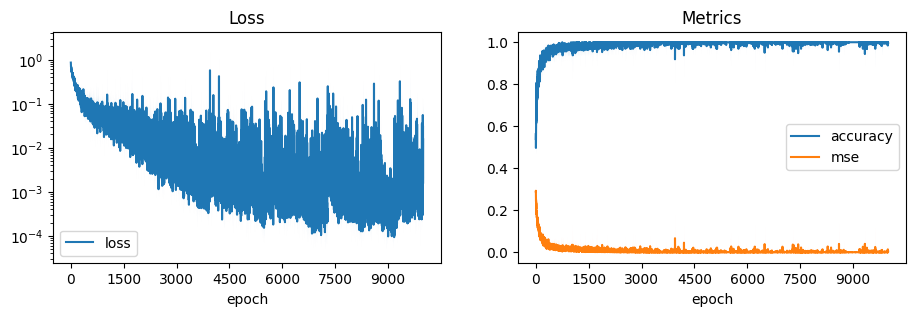

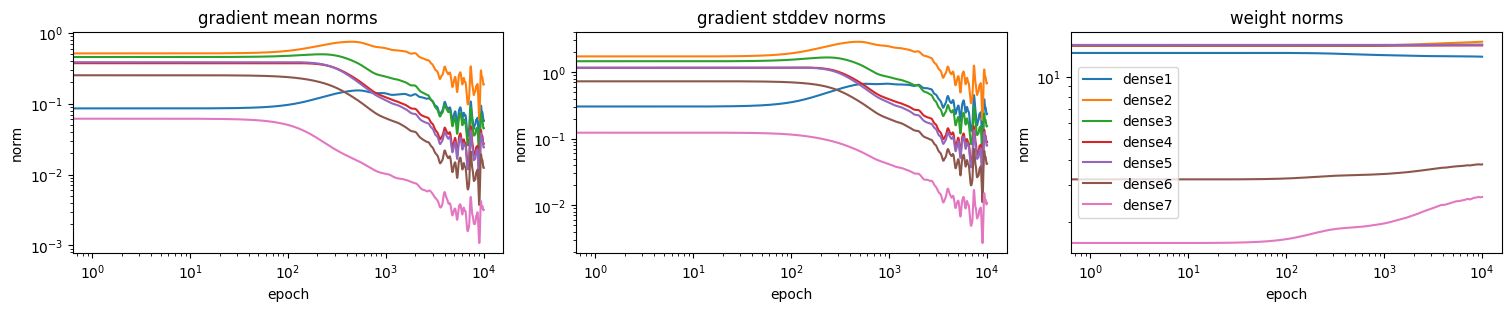

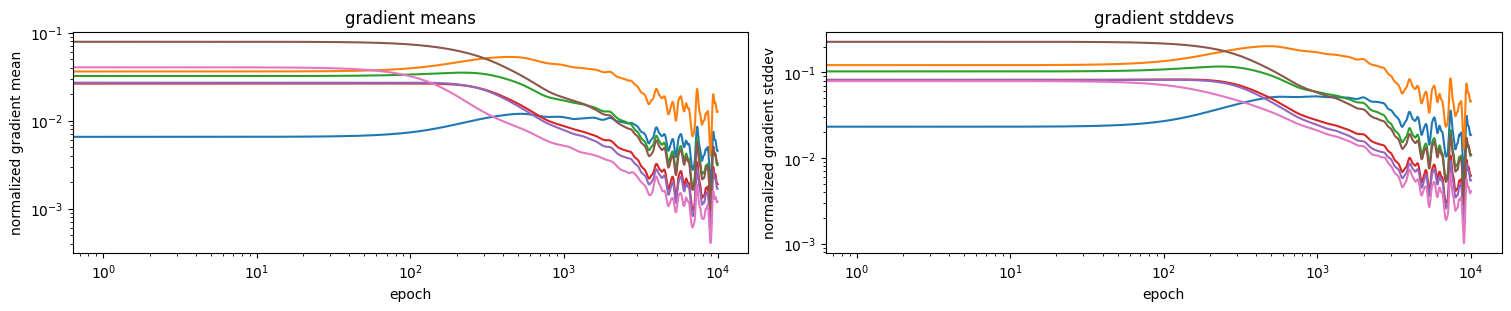

In [13]:
tinstr.plot_train_history(history)
plot_raw_norms(gradient_norms, smoothness=100)
plot_gradient_norms(gradient_norms, smoothness=100.0)

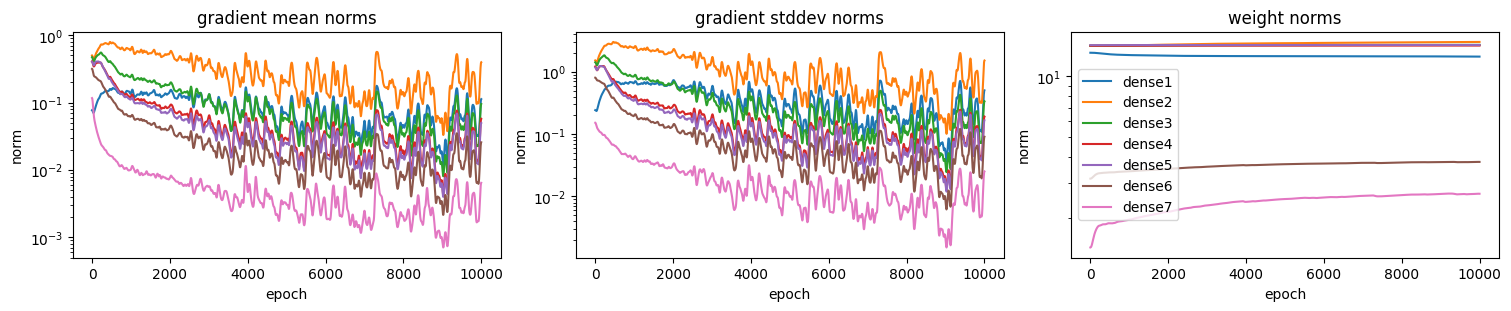

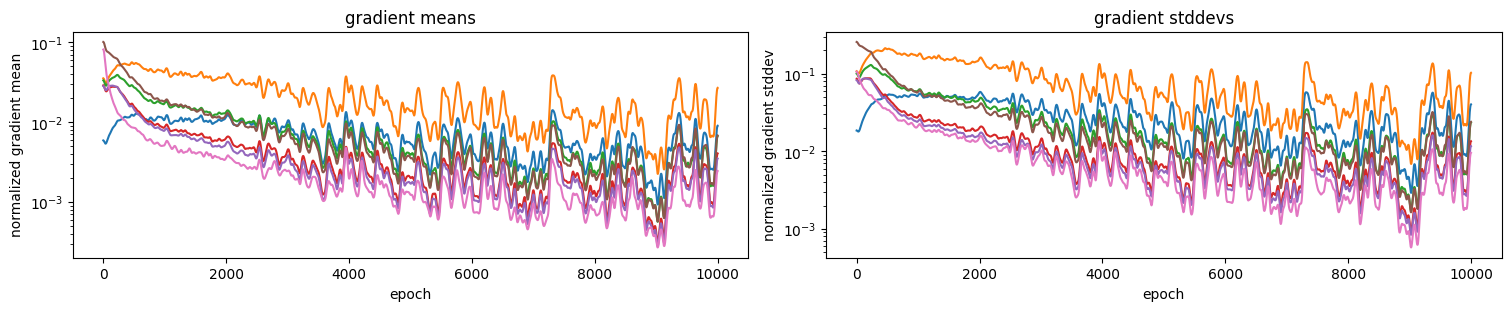

In [16]:
plot_raw_norms(gradient_norms, xlog=False, smoothness=20)
plot_gradient_norms(gradient_norms, xlog=False, smoothness=20.0)

## Appendix: Checking the functionality of the GradientNormCollector callback

In [ ]:
# validating the custom _norm() function
a = tf.random.normal((100,1000))
n1 = tf.norm(a)
n2 = _norm(a)
print(f"{n1=}, {n2=}")

@tf.function
def oob_norm_fn(x):
  return tf.norm(x)

@tf.function
def new_norm_fn(x):
  return _norm(x)

def test_fn(fn, iterations, shape=(100, 1000)):
  start = tf.timestamp()
  res = 0.0
  for i in range(iterations):
    x = tf.random.normal(shape)
    res = res + fn(a)
  duration = (tf.timestamp() - start).numpy()
  res = res.numpy()
  return res, duration

print(f"Measuring...")
r1, d1 = test_fn(oob_norm_fn, 2000)
r2, d2 = test_fn(new_norm_fn, 2000)

print(f"Out-of-box tf.norm(): {r1} in {d1} ms")
print(f"New _norm() function: {r2} in {d2} ms -- {((d1-d2)/d1)*100:.1f}% faster")

In [37]:
gradient_norms = GradientNormCollector()

tf.config.run_functions_eagerly(run_eagerly=True)

model = binary_classification_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])
train_X, train_Y = binary_classification_dataset()
dataset = tf.data.Dataset.from_tensor_slices((train_X, train_Y)).batch(32)
history = tinstr.fit(model, dataset, epochs=5, verbose=0, callbacks=[tinstr.LessVerboseProgressLogger(), gradient_norms, tinstr.HistoryStats(per_step=True)])

Epoch     1 - 1.44s/epoch: accuracy: 0.5333  loss: 0.7910  mse: 0.2827  
on_epoch_end(epoch=0)
  gm[0]: (2, 100), gm^2[0]: (2, 100), w[0]: (2, 100)
  ||gm[0]||: 0.07611936330795288, ||gm^2[0]||: 0.19541649520397186, w[0]: 13.092530250549316
Epoch     2 - 1.44s/epoch: accuracy: 0.5900  loss: 0.7017  mse: 0.2516  
on_epoch_end(epoch=1)
  gm[0]: (2, 100), gm^2[0]: (2, 100), w[0]: (2, 100)
  ||gm[0]||: 0.06545374542474747, ||gm^2[0]||: 0.1896251142024994, w[0]: 13.091177940368652
Epoch     3 - 1.77s/epoch: accuracy: 0.6000  loss: 0.6996  mse: 0.2469  
on_epoch_end(epoch=2)
  gm[0]: (2, 100), gm^2[0]: (2, 100), w[0]: (2, 100)
  ||gm[0]||: 0.06025608256459236, ||gm^2[0]||: 0.16404978930950165, w[0]: 13.090825080871582
Epoch     4 - 2.19s/epoch: accuracy: 0.6267  loss: 0.6881  mse: 0.2434  
on_epoch_end(epoch=3)
  gm[0]: (2, 100), gm^2[0]: (2, 100), w[0]: (2, 100)
  ||gm[0]||: 0.05351445823907852, ||gm^2[0]||: 0.17063908278942108, w[0]: 13.090375900268555
Epoch     5 - 1.71s/epoch: accuracy: 

grad_means: (5, 16), grad_stddevs: (5, 16), weight_means: (5, 16)


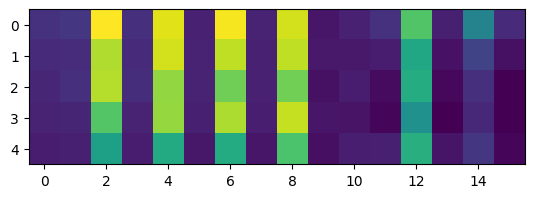

In [38]:
gm, gstd, wm = gradient_norms.collected_norms
print(f"grad_means: {gm.shape}, grad_stddevs: {gstd.shape}, weight_means: {wm.shape}")
plt.imshow(gm)

means: (5, 16), stddevs: (5, 16)


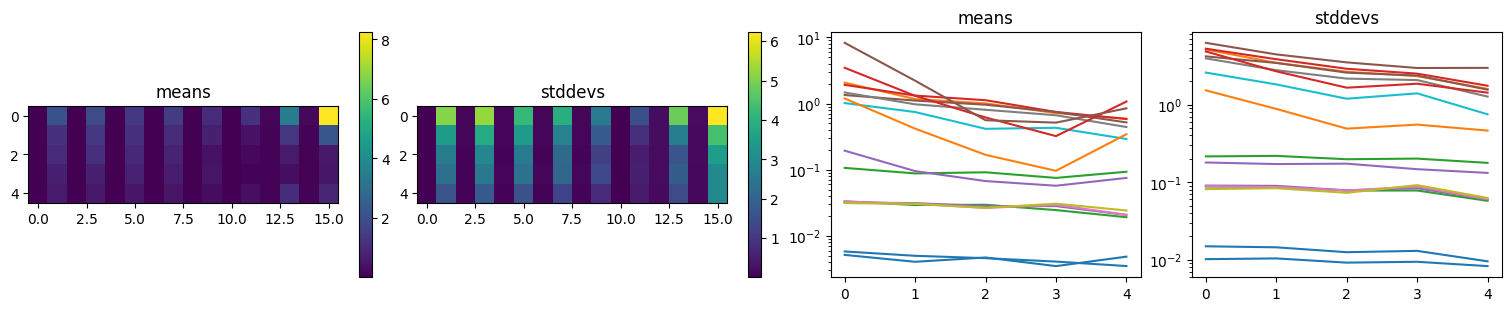

In [42]:
means, stddevs = gradient_norms.normalized_stats
print(f"means: {means.shape}, stddevs: {stddevs.shape}")

plt.figure(figsize=(15,3), layout='constrained')

plt.subplot(1,4,1)
plt.title("means")
plt.imshow(means)
plt.colorbar()

plt.subplot(1,4,2)
plt.title("stddevs")
plt.imshow(stddevs)
plt.colorbar()

plt.subplot(1,4,3)
plt.title("means")
plt.plot(means)
plt.yscale('log')

plt.subplot(1,4,4)
plt.title("stddevs")
plt.plot(stddevs)
plt.yscale('log')

plt.show()

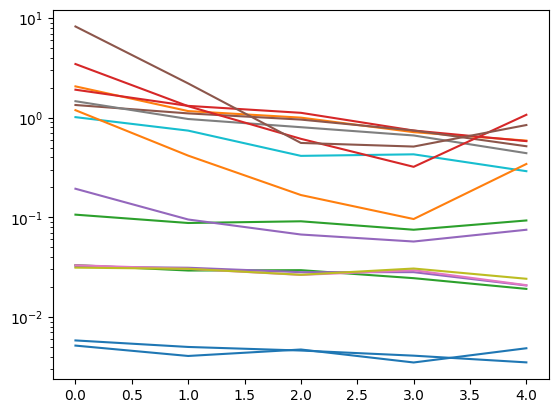

In [40]:
plt.plot(means)
plt.yscale('log')

means: (5, 8), stddevs: (5, 8), layers: [0, 1, 3, 4, 6, 7, 8, 9]


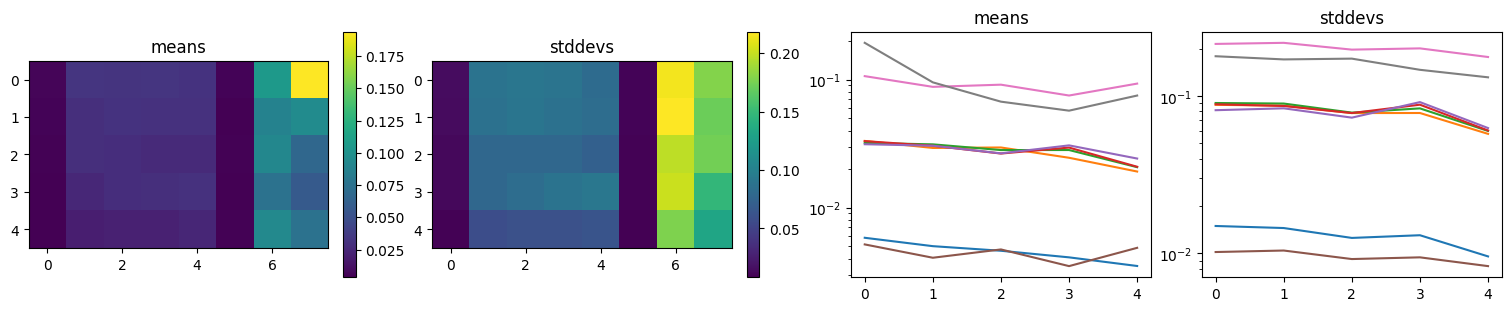

In [43]:
means, stddevs = gradient_norms.normalized_stats_by_layer
l_indices = gradient_norms.normalized_stats_layers
print(f"means: {means.shape}, stddevs: {stddevs.shape}, layers: {l_indices}")

plt.figure(figsize=(15,3), layout='constrained')

plt.subplot(1,4,1)
plt.title("means")
plt.imshow(means)
plt.colorbar()

plt.subplot(1,4,2)
plt.title("stddevs")
plt.imshow(stddevs)
plt.colorbar()

plt.subplot(1,4,3)
plt.title("means")
plt.plot(means)
plt.yscale('log')

plt.subplot(1,4,4)
plt.title("stddevs")
plt.plot(stddevs)
plt.yscale('log')

plt.show()

All layer names:           ['dense_70', 'dense_71', 'dropout_20', 'dense_72', 'dense_73', 'dropout_21', 'dense_74', 'batch_normalization_10', 'dense_75', 'dense_76']
Filtered layer indices:    [0, 1, 3, 4, 6, 8, 9]
Filtered layer names:      ['dense_70', 'dense_71', 'dense_72', 'dense_73', 'dense_74', 'dense_75', 'dense_76']
Filtered variable indices: [0, 2, 4, 6, 8, 12, 14]
means: (5, 7), stddevs: (5, 7), layers: [0, 1, 3, 4, 6, 7, 8, 9]


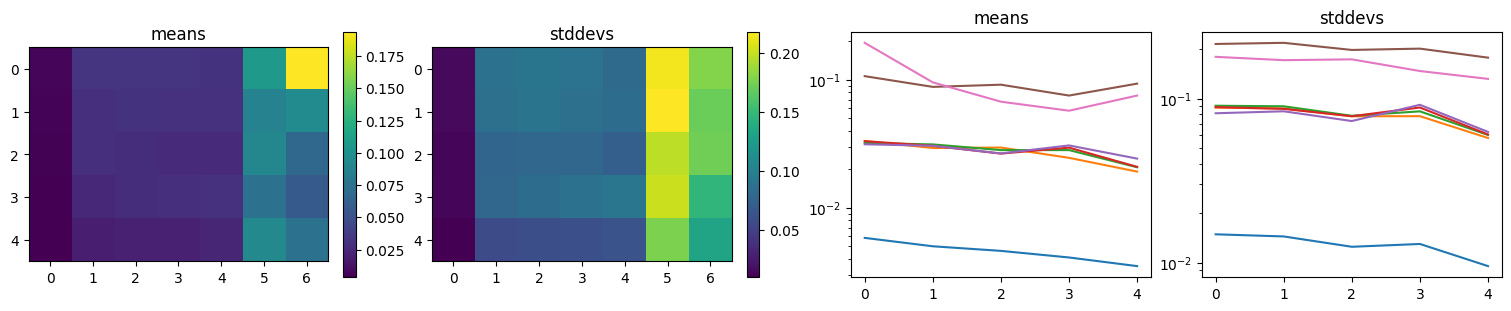

In [56]:
# Instead, picking variables by skipping Dropout and BatchNorm layers (BatchNorm has trainable variables, which might mess up the cleanliness of the results)
print(f"All layer names:           {[layer.name for layer in model.layers]}")
print(f"Filtered layer indices:    {layer_indices_of_interest(model)}")
print(f"Filtered layer names:      {[model.layers[l_idx].name for l_idx in layer_indices_of_interest(model)]}")
print(f"Filtered variable indices: {trainable_variable_indices_of_interest(model)}")

filtered_variable_indices = trainable_variable_indices_of_interest(model)
means, stddevs = gradient_norms.normalized_stats
means = means[:, filtered_variable_indices]
stddevs = stddevs[:, filtered_variable_indices]
print(f"means: {means.shape}, stddevs: {stddevs.shape}, layers: {l_indices}")


plt.figure(figsize=(15,3), layout='constrained')

plt.subplot(1,4,1)
plt.title("means")
plt.imshow(means)
plt.colorbar()

plt.subplot(1,4,2)
plt.title("stddevs")
plt.imshow(stddevs)
plt.colorbar()

plt.subplot(1,4,3)
plt.title("means")
plt.plot(means)
plt.yscale('log')

plt.subplot(1,4,4)
plt.title("stddevs")
plt.plot(stddevs)
plt.yscale('log')

plt.show()